# Sheetpile: CROW 2 stage linear elastic

This notebook runs the CROW two-stage linear elastic sheet pile model directly with **Kratos GeoMechanicsApplication**.

To run this notebook, first follow the project setup in [Getting started](../../getting_started.md). Then open this notebook together with the other files in `examples/crow_case` in VS Code or a similar IDE. Then make sure you have an active Python environment with Kratos installed in your IDE.

The notebook uses `matplotlib` for plotting, so install it in the active environment if needed:

```bash
pip install matplotlib
```

To execute the notebook from VS Code or another IDE, the same environment also needs `ipykernel` installed:

```bash
pip install ipykernel
```

The model consists of two stages:

* `1_Initial_stage.json`
* `2_Final_equilibrium.json`

The second stage reuses the model part created in the first stage, so both stages are run with the same `Kratos.Model()` instance.

### Model description

This CROW validation case represents a sheet pile wall in layered clay and sand with a surcharge on the retained side and a spring support/anchor connected to the wall. The Kratos model uses a linear elastic soil response, interface elements along the sheet pile, a Timoshenko beam representation for the sheet pile, and a truss representation for the anchor.

The model used in this notebook is a simplified two-stage version of the more detailed staged-construction model described in the upstream Kratos documentation. Here, the stress initialization is performed first, after which all activation and deactivation processes are handled together in the final equilibrium stage.

The full model background, parameter derivations, and complete staged-construction description are documented in the upstream Kratos CROW documentation: [CROW model documentation](https://github.com/KratosMultiphysics/Kratos/blob/d4141ad654655f693a20dfe587e8bd9076a2059a/applications/GeoMechanicsApplication/tests/crow_validation/CROW_documentation.md).

The simplified model contains the following stages:

1. **Initial stage**

   - The entire soil domain is active, while the anchor, sheet pile, and interfaces on both sides of the soil are inactive.
   - Master-slave constraints are applied where the soil will later be separated by the sheet pile. This preserves continuity of the displacement field during the initial stress calculation.
   - The only applied load is self-weight.
   - At the end of this stage, a $K_0$ procedure initializes the horizontal stress field. This $K_0$ procedure requires linear elastic materials for all soil parts.

2. **Final equilibrium**

   - The excavated soil parts are deactivated.
   - The sheet pile and the interfaces attached to its left and right sides are activated.
   - The master-slave constraints are deactivated, after which the interface elements represent the displacement discontinuity at the diaphragm wall location.
   - A surface load is applied to part of the soil surface on the right-hand side.
   - The anchor is activated.

### Imports

The notebook uses the regular Kratos analysis class instead of the probabilistic analysis wrapper.

In [31]:
from contextlib import contextmanager
from pathlib import Path
import os

import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
from KratosMultiphysics.GeoMechanicsApplication.geomechanics_analysis import GeoMechanicsAnalysis
from KratosMultiphysics.GeoMechanicsApplication.gid_output_file_reader import GiDOutputFileReader

### Model location

Set `PROJECT_PATH` to the folder that contains the Kratos input files for this CROW case.

In [32]:
NOTEBOOK_DIR = Path.cwd()

STAGE_FILES = [
    "1_Initial_stage.json",
    "2_Final_equilibrium.json",
]

REQUIRED_MODEL_FILES = [
    *STAGE_FILES,
    "crow_validation_gid.mdpa",
    "linear_elastic_material.json",
]

PROJECT_PATH = NOTEBOOK_DIR / "KratosCROW_2Stage_LinearElastic"

missing_model_files = [
    required_file
    for required_file in REQUIRED_MODEL_FILES
    if not (PROJECT_PATH / required_file).exists()
]
if missing_model_files:
    raise FileNotFoundError(
        "Missing CROW Kratos model files in the model folder: "
        f"{missing_model_files}"
    )

DSHEET_COMPARISON_FILE = NOTEBOOK_DIR / "2_Final_equilibrium_comparison_DSheetPiling.csv"
assert DSHEET_COMPARISON_FILE.exists(), "Missing D-Sheet Piling comparison file"

print(f"Using Kratos model files from: {PROJECT_PATH}")

Using Kratos model files from: c:\Checkouts\Deltares\Kratos-GeoMechanicsApplication-Documentation\kratos-docs\docs\examples\crow_case\KratosCROW_2Stage_LinearElastic


### Run Kratos

Kratos resolves model, material, and output paths relative to the current working directory. The helper below temporarily switches to the project folder while the stages run.

In [33]:
@contextmanager
def working_directory(path):
    previous_directory = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(previous_directory)


def run_kratos_stages(project_path, stage_files):
    model = Kratos.Model()

    with working_directory(project_path):
        for stage_file in stage_files:
            with open(stage_file, "r") as parameter_file:
                parameters = Kratos.Parameters(parameter_file.read())

            analysis = GeoMechanicsAnalysis(model, parameters)
            analysis.Run()

    return model

Run the two-stage calculation.

In [34]:
model = run_kratos_stages(PROJECT_PATH, STAGE_FILES)

### Extract sheet pile results

The final-stage beam results are read from the GiD result file written by Kratos. This follows the same route as the CROW validation test and the original notebook output extraction.

In [35]:
def get_sorted_beam_nodes(model, model_part_name="PorousDomain.Beam"):
    beam_model_part = model.GetModelPart(model_part_name)
    return sorted(beam_model_part.Nodes, key=lambda node: node.Y)


def read_final_stage_wall_results(project_path, model):
    beam_nodes = get_sorted_beam_nodes(model)
    node_ids = [node.Id for node in beam_nodes]
    y_coordinates = [node.Y for node in beam_nodes]

    output_file = project_path / "gid_output" / "2_Final_equilibrium.post.res"
    reader = GiDOutputFileReader()
    output_data = reader.read_output_from(output_file)

    bending_moments = reader.nodal_values_at_time(
        "BENDING_MOMENT", 1.0, output_data, node_ids=node_ids
    )
    shear_forces = reader.nodal_values_at_time(
        "SHEAR_FORCE", 1.0, output_data, node_ids=node_ids
    )
    displacements = reader.nodal_values_at_time(
        "DISPLACEMENT", 1.0, output_data, node_ids=node_ids
    )
    horizontal_displacements = [value[0] for value in displacements]

    return beam_nodes, y_coordinates, bending_moments, shear_forces, horizontal_displacements


beam_nodes, y_beam, bending_moment, shear_force, horizontal_displacement = (
    read_final_stage_wall_results(PROJECT_PATH, model)
)

### Read D-Sheet Piling comparison

The comparison file contains level, bending moment, shear force, and horizontal displacement. The sign convention for moment and shear force is opposite to the Kratos convention, so those values are multiplied by `-1` before plotting.

In [36]:
def read_dsheet_piling_comparison(file_path):
    levels = []
    bending_moments = []
    shear_forces = []
    horizontal_displacements = []

    with open(file_path, "r") as comparison_file:
        for line in comparison_file:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            level, moment, shear, displacement = [
                float(value.strip()) for value in line.split(",")
            ]
            levels.append(level)
            bending_moments.append(-moment)
            shear_forces.append(-shear)
            horizontal_displacements.append(displacement / 1000.0)

    return levels, bending_moments, shear_forces, horizontal_displacements


(
    dsheet_y,
    dsheet_bending_moment,
    dsheet_shear_force,
    dsheet_horizontal_displacement,
) = read_dsheet_piling_comparison(DSHEET_COMPARISON_FILE)

### Plot final-stage wall response

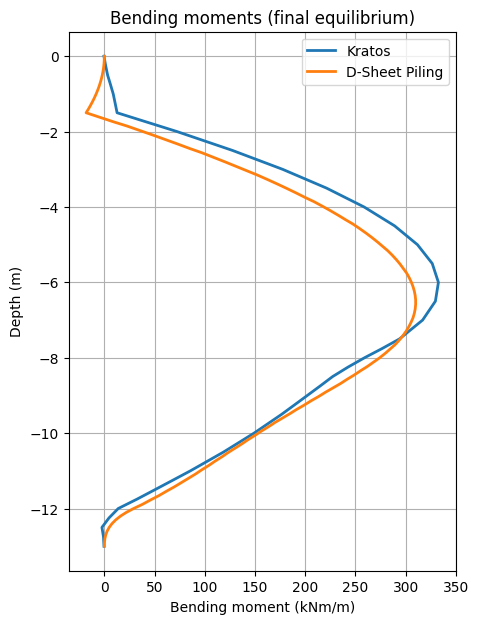

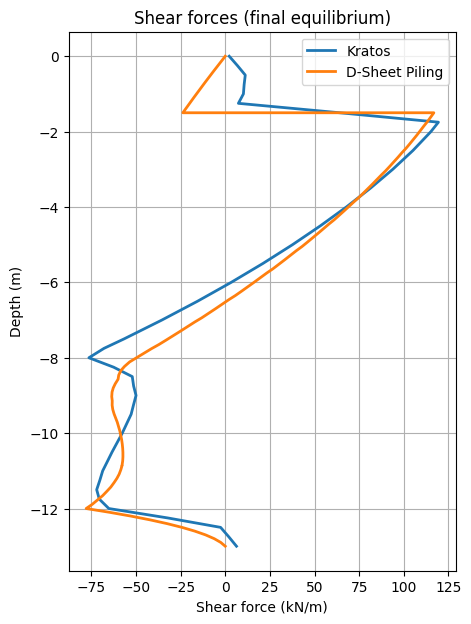

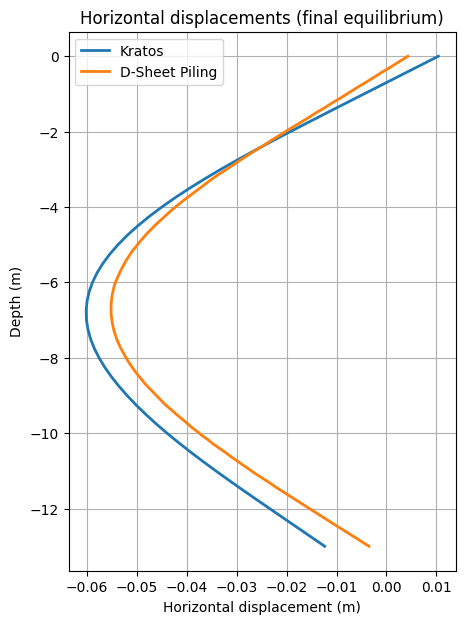

In [37]:
def to_kilo_units(values):
    return [value / 1000.0 for value in values]


def plot_wall_result(
    kratos_values,
    kratos_y_coordinates,
    dsheet_values,
    dsheet_y_coordinates,
    xlabel,
    title,
):
    plt.figure(figsize=(5, 7))
    plt.plot(kratos_values, kratos_y_coordinates, "-", linewidth=2, label="Kratos")
    plt.plot(
        dsheet_values,
        dsheet_y_coordinates,
        "-",
        linewidth=2,
        label="D-Sheet Piling",
    )
    plt.grid(True)
    plt.xlabel(xlabel)
    plt.ylabel("Depth (m)")
    plt.title(title)
    plt.legend()


plot_wall_result(
    to_kilo_units(bending_moment),
    y_beam,
    dsheet_bending_moment,
    dsheet_y,
    "Bending moment (kNm/m)",
    "Bending moments (final equilibrium)",
)

plot_wall_result(
    to_kilo_units(shear_force),
    y_beam,
    dsheet_shear_force,
    dsheet_y,
    "Shear force (kN/m)",
    "Shear forces (final equilibrium)",
)

plot_wall_result(
    horizontal_displacement,
    y_beam,
    dsheet_horizontal_displacement,
    dsheet_y,
    "Horizontal displacement (m)",
    "Horizontal displacements (final equilibrium)",
)

### Summary values

In [38]:
print(f"Number of beam nodes: {len(beam_nodes)}")
print(f"Maximum absolute bending moment: {max(abs(value) for value in bending_moment):.6g} Nm/m")
print(f"Maximum absolute shear force: {max(abs(value) for value in shear_force):.6g} N/m")
print(
    "Maximum absolute horizontal displacement: "
    f"{max(abs(value) for value in horizontal_displacement):.6g} m"
)

Number of beam nodes: 53
Maximum absolute bending moment: 332624 Nm/m
Maximum absolute shear force: 119417 N/m
Maximum absolute horizontal displacement: 0.0601996 m
